# 🔆 Solar Power Plant Analysis - Jupyter Notebook Version

Dashboard analisis lengkap untuk data Solar Power Plant dengan fitur:
- **Data Loading & Cleaning**: Membaca dan membersihkan data Excel
- **Overview & Statistik**: Ringkasan kinerja dan pola produksi
- **Analisis Temporal**: Pola harian, mingguan, dan musiman
- **Korelasi & Hubungan**: Analisis hubungan antar variabel
- **Forecasting**: Prediksi produksi menggunakan multiple models
- **Business Insights**: Wawasan bisnis dan rekomendasi

*Versi ringkas dari Streamlit dashboard untuk eksplorasi data interaktif*

In [68]:
# Import library yang dibutuhkan
import glob
import math
import os
import re
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine learning libraries
try:
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.linear_model import LinearRegression, Ridge
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.preprocessing import StandardScaler
    SKLEARN_OK = True
    print("✓ Scikit-learn loaded successfully")
except ImportError:
    SKLEARN_OK = False
    print("⚠️ Scikit-learn not available")

# Plotly untuk visualisasi interaktif (opsional)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_OK = True
    print("✓ Plotly loaded successfully")
except ImportError:
    PLOTLY_OK = False
    print("⚠️ Plotly not available - using matplotlib")

# Konfigurasi
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

# Setup untuk tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("🔧 Setup completed!")

✓ Scikit-learn loaded successfully
✓ Plotly loaded successfully
🔧 Setup completed!


In [69]:
## 📊 Data Loading & Helper Functions

# Mapping kolom standar
STANDARD_COLS = {
    "date_hour": ["Date - Hour (NMT)", "Date – Hour (NMT)", "Date—Hour (NMT)", 
                  "Date Hour (NMT)", "Date_Hour_NMT", "Date/Hour", "Datetime", "DateTime"],
    "wind_speed": ["Wind Speed","Wind_Speed"],
    "sunshine": ["Sunshine"],
    "air_pressure": ["Air Pressure","Air_Pressure"],
    "radiation": ["Radiation"],
    "air_temperature": ["Air Temperature","Air_Temperature"],
    "relative_air_humidity": ["Relative Air Humidity","Relative_Air_Humidity"],
    "system_production": ["System Production","System_Production","Production",
                         "SystemProduction","Actual","y","Y"]
}

def find_column(df, col_key):
    """Cari kolom berdasarkan nama standar"""
    for col in STANDARD_COLS[col_key]:
        if col in df.columns:
            return col
    return None

def clean_numeric(series):
    """Bersihkan data numerik dengan format Eropa/internasional"""
    if series.dtype == 'O':
        s = series.astype(str)
        s = s.str.replace(r"[^\d,\.\-]+", "", regex=True)
        
        # Handle format Eropa (koma sebagai desimal)
        has_both = s.str.contains(",", na=False) & s.str.contains(r"\.", na=False, regex=True)
        s = np.where(
            has_both,
            s.str.replace(r"\.", "", regex=True).str.replace(",", ".", regex=False),
            s.str.replace(",", ".", regex=False)
        )
        series = pd.Series(s)
    
    return pd.to_numeric(series, errors="coerce")

def parse_datetime(s):
    """Parse datetime dengan berbagai format"""
    def parse_one(x):
        if pd.isna(x): 
            return pd.NaT
        
        if isinstance(x, pd.Timestamp):
            return x
        
        x_str = str(x).strip()
        formats = [
            "%d/%m/%Y %H:%M",
            "%m/%d/%Y %H:%M", 
            "%d.%m.%Y %H:%M",
            "%Y-%m-%d %H:%M:%S",
            "%Y-%m-%d %H:%M",
            "%d-%m-%Y %H:%M"
        ]
        
        for fmt in formats:
            try:
                return pd.to_datetime(x_str, format=fmt)
            except:
                continue
        
        try:
            return pd.to_datetime(x_str, dayfirst=True)
        except:
            return pd.to_datetime(x_str, errors="coerce")
    
    return s.apply(parse_one)

print("✓ Helper functions defined")

✓ Helper functions defined


In [70]:
# Fungsi utama untuk memuat dan membersihkan data Excel
def load_solar_data(filepath, sheet_name=None):
    """
    Load dan bersihkan data solar power plant dari Excel
    """
    try:
        # Baca Excel
        if sheet_name:
            df = pd.read_excel(filepath, sheet_name=sheet_name)
        else:
            # Ambil sheet pertama
            xls = pd.ExcelFile(filepath)
            df = pd.read_excel(filepath, sheet_name=xls.sheet_names[0])
            print(f"📊 Using sheet: {xls.sheet_names[0]}")
        
        # Bersihkan nama kolom
        df.columns = [str(c).strip() for c in df.columns]
        
        # Hapus kolom kosong
        df = df.loc[:, ~(df.columns.str.contains('^Unnamed') & df.isnull().all())]
        
        # Cari kolom tanggal/waktu
        date_col = find_column(df, "date_hour")
        if date_col is None:
            date_like = [c for c in df.columns if re.search(r"(date|time|hour)", c, re.I)]
            date_col = date_like[0] if date_like else None
        
        if date_col is None:
            raise ValueError("Kolom tanggal/jam tidak ditemukan!")
        
        print(f"📅 Found datetime column: {date_col}")
        
        # Clean numeric columns
        numeric_keys = ["wind_speed", "sunshine", "air_pressure", "radiation", 
                       "air_temperature", "relative_air_humidity", "system_production"]
        
        for key in numeric_keys:
            col = find_column(df, key)
            if col and col in df.columns:
                df[col] = clean_numeric(df[col])
        
        # Parse datetime
        df["timestamp"] = parse_datetime(df[date_col])
        
        # Remove invalid timestamps
        before_count = len(df)
        df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
        after_count = len(df)
        
        if before_count != after_count:
            print(f"⚠️ Removed {before_count - after_count} rows with invalid timestamps")
        
        # Rename kolom ke standard names
        rename_map = {}
        for key in STANDARD_COLS:
            col = find_column(df, key)
            if col: 
                rename_map[col] = key
        df = df.rename(columns=rename_map)
        
        # Create time features
        df["hour"] = df["timestamp"].dt.hour
        df["day_of_week"] = df["timestamp"].dt.dayofweek
        df["month"] = df["timestamp"].dt.month
        df["day_of_year"] = df["timestamp"].dt.dayofyear
        
        # Solar-specific features
        df["is_daytime"] = ((df["hour"] >= 6) & (df["hour"] <= 18)).astype(int)
        df["is_peak_solar"] = ((df["hour"] >= 10) & (df["hour"] <= 15)).astype(int)
        
        if "radiation" in df.columns and "system_production" in df.columns:
            # Solar efficiency ratio
            df["solar_efficiency"] = np.where(
                df["radiation"] > 0,
                df["system_production"] / df["radiation"],
                0
            )
        
        print(f"✅ Data loaded successfully: {len(df):,} rows, {df.shape[1]} columns")
        print(f"📊 Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
        
        return df
        
    except Exception as e:
        print(f"❌ Error loading data: {str(e)}")
        return None

# Cari file Excel yang tersedia - HANYA gunakan dataset asli
excel_files = [
    "Solar Power Plant Dataset XLSX.xlsx",  # Dataset asli (HANYA INI)
]

found_file = None
for file in excel_files:
    if os.path.exists(file):
        found_file = file
        print(f"📁 Found Excel file: {file}")
        break

if not found_file:
    # Cari dengan pattern - HANYA dataset asli, JANGAN yang "new"
    pattern_files = glob.glob("*Solar*Power*Plant*Dataset*.xlsx")
    # Filter out files dengan "new" dalam nama
    pattern_files = [f for f in pattern_files if "new" not in f.lower()]
    if pattern_files:
        found_file = pattern_files[0]
        print(f"📁 Found Excel file (pattern): {found_file}")

if found_file:
    print(f"🎯 Will use: {found_file}")
else:
    print("❌ No Excel file found!")

📁 Found Excel file: Solar Power Plant Dataset XLSX.xlsx
🎯 Will use: Solar Power Plant Dataset XLSX.xlsx


## 1. Load Data & Overview

In [71]:
# Load data dari Excel
df = load_solar_data(found_file)

if df is not None:
    # Tampilkan basic info
    print("="*50)
    print("📊 DATASET OVERVIEW")
    print("="*50)
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print()
    
    # Cek missing values
    missing_data = df.isnull().sum()
    missing_pct = (missing_data / len(df)) * 100
    missing_info = pd.DataFrame({
        'Missing Count': missing_data,
        'Missing %': missing_pct
    }).round(2)
    
    print("Missing Data Summary:")
    print(missing_info[missing_info['Missing Count'] > 0])
    print()
    
    # Basic statistics untuk kolom numerik
    if 'system_production' in df.columns:
        print("Production Statistics:")
        prod_stats = df['system_production'].describe()
        print(prod_stats)
        
        # Non-zero production stats
        non_zero_prod = df[df['system_production'] > 0]['system_production']
        if len(non_zero_prod) > 0:
            print(f"\nNon-zero production stats:")
            print(f"Count: {len(non_zero_prod):,} ({len(non_zero_prod)/len(df)*100:.1f}%)")
            print(f"Mean: {non_zero_prod.mean():.2f}")
            print(f"Max: {non_zero_prod.max():.2f}")
    
    print("\n✅ Data loaded successfully!")
    
    # Preview data
    print("\n📋 Data Preview (first 5 rows):")
    display(df.head())
else:
    print("❌ Failed to load data!")

📊 Using sheet: Solar Power Plant Data
📅 Found datetime column: Date - Hour (NMT)
✅ Data loaded successfully: 744 rows, 16 columns
📊 Date range: 2017-01-01 00:00:00 to 2017-01-31 23:00:00
📊 DATASET OVERVIEW
Shape: (744, 16)
Columns: ['date_hour', 'wind_speed', 'sunshine', 'air_pressure', 'radiation', 'air_temperature', 'relative_air_humidity', 'system_production', 'timestamp', 'hour', 'day_of_week', 'month', 'day_of_year', 'is_daytime', 'is_peak_solar', 'solar_efficiency']

Missing Data Summary:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Production Statistics:
count     744.000000
mean       69.166162
std       214.746885
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      1606.333300
Name: system_production, dtype: float64

Non-zero production stats:
Count: 139 (18.7%)
Mean: 370.21
Max: 1606.33

✅ Data loaded successfully!

📋 Data Preview (first 5 rows):
✅ Data loaded successfully: 744 rows, 16 columns
📊 Date range: 2017-01-0

,date_hour,wind_speed,sunshine,air_pressure,radiation,air_temperature,relative_air_humidity,system_production,timestamp,hour,day_of_week,month,day_of_year,is_daytime,is_peak_solar,solar_efficiency
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0,2017-01-01 00:00:00,0,6,1,1,0,0,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0,2017-01-01 01:00:00,1,6,1,1,0,0,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0,2017-01-01 02:00:00,2,6,1,1,0,0,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0,2017-01-01 03:00:00,3,6,1,1,0,0,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0,2017-01-01 04:00:00,4,6,1,1,0,0,0.0


## 2. Analisis Pola Temporal

📈 HOURLY PRODUCTION PATTERN
        mean      max     std
hour                         
0       0.00     0.00    0.00
1       0.00     0.00    0.00
2       0.00     0.00    0.00
3       0.00     0.00    0.00
4       0.00     0.00    0.00
5       0.00     0.00    0.00
6       0.00     0.00    0.00
7       0.00     0.00    0.00
8       0.00     0.00    0.00
9       0.00     0.00    0.00
10      5.93   128.00   23.80
11    159.72   660.50  186.11
12    572.30  1455.00  450.72
13    565.56  1606.33  459.33
14    237.61   573.83  176.36
15    106.86   478.33  118.76
16     12.03   101.33   24.53
17      0.00     0.00    0.00
18      0.00     0.00    0.00
19      0.00     0.00    0.00
20      0.00     0.00    0.00
21      0.00     0.00    0.00
22      0.00     0.00    0.00
23      0.00     0.00    0.00



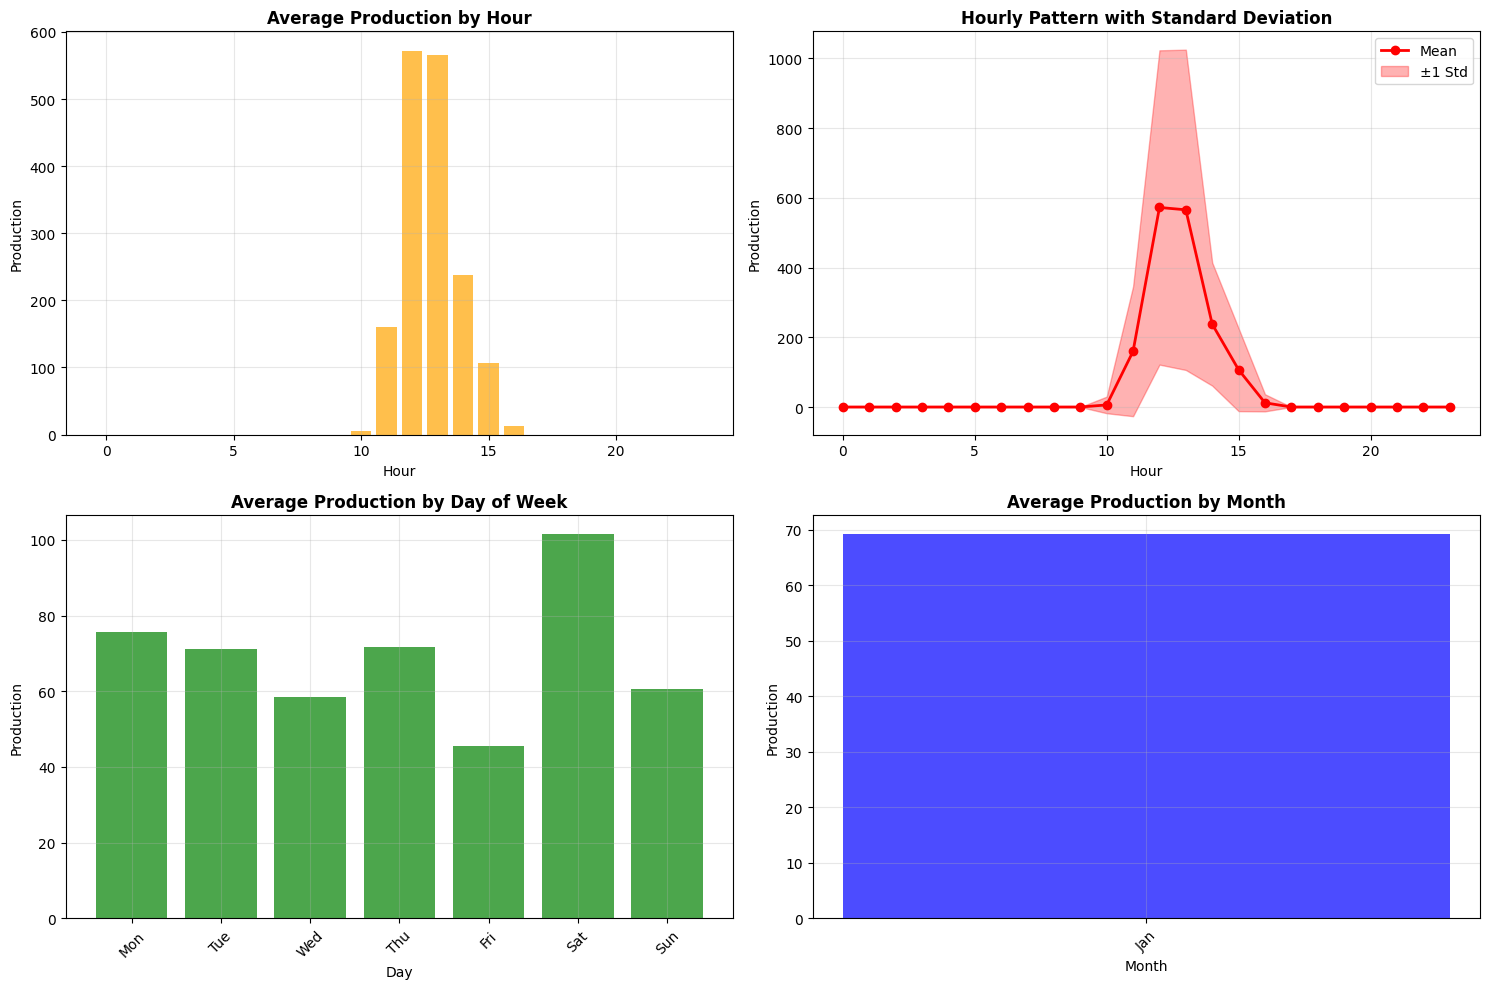

🔍 KEY INSIGHTS:
• Peak production hour: 12:00 with 572.30 average production
• Production starts around: 10:00
• Production stops around: 16:00
• Most consistent hour (lowest std): 0:00
• Most variable hour (highest std): 13:00


In [72]:
# Analisis pola harian
if 'system_production' in df.columns:
    # Pola harian rata-rata
    hourly_pattern = df.groupby('hour')['system_production'].agg(['mean', 'max', 'std']).round(2)
    
    print("📈 HOURLY PRODUCTION PATTERN")
    print("="*40)
    print(hourly_pattern)
    print()
    
    # Visualisasi pola harian
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Rata-rata produksi per jam
    axes[0,0].bar(hourly_pattern.index, hourly_pattern['mean'], 
                  color='orange', alpha=0.7)
    axes[0,0].set_title('Average Production by Hour', fontweight='bold')
    axes[0,0].set_xlabel('Hour')
    axes[0,0].set_ylabel('Production')
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Pola harian dengan standar deviasi
    axes[0,1].plot(hourly_pattern.index, hourly_pattern['mean'], 
                   'o-', color='red', linewidth=2, label='Mean')
    axes[0,1].fill_between(hourly_pattern.index, 
                          hourly_pattern['mean'] - hourly_pattern['std'],
                          hourly_pattern['mean'] + hourly_pattern['std'],
                          alpha=0.3, color='red', label='±1 Std')
    axes[0,1].set_title('Hourly Pattern with Standard Deviation', fontweight='bold')
    axes[0,1].set_xlabel('Hour')
    axes[0,1].set_ylabel('Production')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Pola mingguan
    weekly_pattern = df.groupby('day_of_week')['system_production'].mean()
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    axes[1,0].bar(day_names, weekly_pattern.values, color='green', alpha=0.7)
    axes[1,0].set_title('Average Production by Day of Week', fontweight='bold')
    axes[1,0].set_xlabel('Day')
    axes[1,0].set_ylabel('Production')
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].grid(True, alpha=0.3)
    
    # 4. Pola bulanan
    monthly_pattern = df.groupby('month')['system_production'].mean()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    available_months = monthly_pattern.index
    axes[1,1].bar([month_names[m-1] for m in available_months], 
                  monthly_pattern.values, color='blue', alpha=0.7)
    axes[1,1].set_title('Average Production by Month', fontweight='bold')
    axes[1,1].set_xlabel('Month')
    axes[1,1].set_ylabel('Production')
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Key insights
    peak_hour = hourly_pattern['mean'].idxmax()
    peak_production = hourly_pattern['mean'].max()
    
    print("🔍 KEY INSIGHTS:")
    print(f"• Peak production hour: {peak_hour}:00 with {peak_production:.2f} average production")
    print(f"• Production starts around: {hourly_pattern[hourly_pattern['mean'] > 0].index.min()}:00")
    print(f"• Production stops around: {hourly_pattern[hourly_pattern['mean'] > 0].index.max()}:00")
    print(f"• Most consistent hour (lowest std): {hourly_pattern['std'].idxmin()}:00")
    print(f"• Most variable hour (highest std): {hourly_pattern['std'].idxmax()}:00")
else:
    print("⚠️ system_production column not found")

## 3. Analisis Korelasi & Hubungan Antar Variabel

📊 CORRELATION MATRIX
                       wind_speed  sunshine  air_pressure  radiation  \
wind_speed                  1.000    -0.092        -0.319     -0.090   
sunshine                   -0.092     1.000         0.006      0.757   
air_pressure               -0.319     0.006         1.000      0.039   
radiation                  -0.090     0.757         0.039      1.000   
air_temperature             0.305     0.019        -0.349      0.117   
relative_air_humidity      -0.279    -0.369         0.223     -0.226   
system_production          -0.093     0.451         0.025      0.777   
solar_efficiency           -0.035     0.192        -0.017      0.540   

                       air_temperature  relative_air_humidity  \
wind_speed                       0.305                 -0.279   
sunshine                         0.019                 -0.369   
air_pressure                    -0.349                  0.223   
radiation                        0.117                 -0.226   
air_t

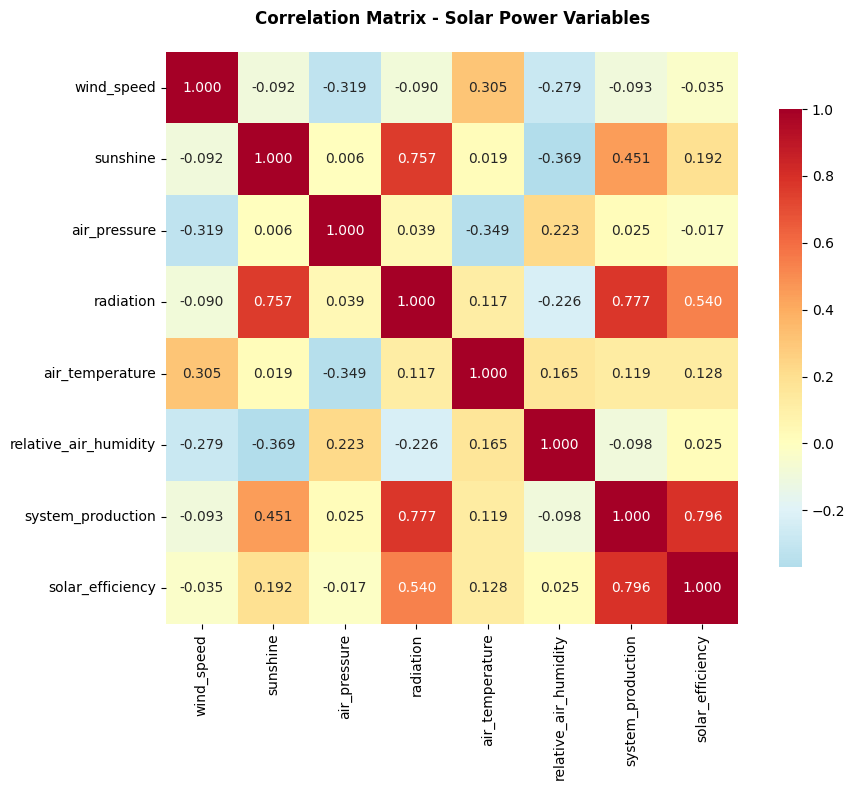

🔗 CORRELATION WITH SYSTEM PRODUCTION:
---------------------------------------------
solar_efficiency    :  0.796 (Strong positive)
radiation           :  0.777 (Strong positive)
sunshine            :  0.451 (Moderate positive)
air_temperature     :  0.119 (Weak positive)
relative_air_humidity: -0.098 (Weak negative)
wind_speed          : -0.093 (Weak negative)
air_pressure        :  0.025 (Weak positive)



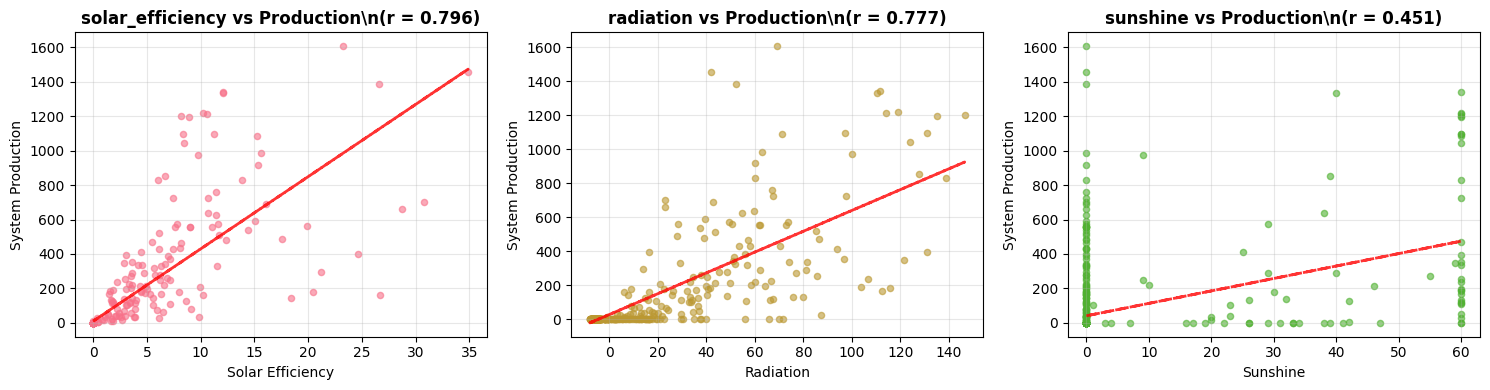

📈 SUMMARY STATISTICS:
------------------------------


,count,mean,std,min,25%,50%,75%,max
wind_speed,744.0,1.80,1.42,0.0,0.88,1.40,2.10,8.90
sunshine,744.0,3.89,13.39,0.0,0.00,0.00,0.00,60.00
air_pressure,744.0,1015.04,15.35,965.9,1008.10,1020.70,1025.20,1038.90
radiation,744.0,6.56,27.29,-8.1,-6.40,-5.45,2.48,146.50
air_temperature,744.0,-1.45,3.32,-12.4,-3.20,-1.00,0.90,5.30
relative_air_humidity,744.0,86.92,12.53,42.0,81.00,91.00,97.00,100.00
system_production,744.0,69.17,214.75,0.0,0.00,0.00,0.00,1606.33
solar_efficiency,744.0,1.40,4.08,0.0,0.00,0.00,0.00,34.89


In [73]:
# Analisis korelasi antar variabel
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude time-based columns untuk korelasi yang lebih meaningful  
exclude_cols = ['hour', 'day_of_week', 'month', 'day_of_year', 'is_daytime', 'is_peak_solar']
analysis_cols = [col for col in numeric_cols if col not in exclude_cols]

if len(analysis_cols) >= 2:
    # Correlation matrix
    corr_matrix = df[analysis_cols].corr()
    
    print("📊 CORRELATION MATRIX")
    print("="*50)
    print(corr_matrix.round(3))
    print()
    
    # Visualisasi correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
                square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
    plt.title('Correlation Matrix - Solar Power Variables', fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Analisis korelasi dengan system_production
    if 'system_production' in analysis_cols:
        prod_corr = corr_matrix['system_production'].drop('system_production').sort_values(ascending=False, key=abs)
        
        print("🔗 CORRELATION WITH SYSTEM PRODUCTION:")
        print("-" * 45)
        for var, corr_val in prod_corr.items():
            strength = "Strong" if abs(corr_val) > 0.7 else "Moderate" if abs(corr_val) > 0.4 else "Weak"
            direction = "positive" if corr_val > 0 else "negative"
            print(f"{var:20s}: {corr_val:6.3f} ({strength} {direction})")
        print()
        
        # Scatter plots untuk top correlations
        top_vars = prod_corr.abs().head(3).index.tolist()
        
        if len(top_vars) > 0:
            n_plots = min(3, len(top_vars))
            fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
            if n_plots == 1:
                axes = [axes]
            
            for i, var in enumerate(top_vars[:n_plots]):
                # Remove NaN values for plotting
                plot_data = df[[var, 'system_production']].dropna()
                
                axes[i].scatter(plot_data[var], plot_data['system_production'], 
                              alpha=0.6, s=20, color=f'C{i}')
                axes[i].set_xlabel(var.replace('_', ' ').title())
                axes[i].set_ylabel('System Production')
                axes[i].set_title(f'{var} vs Production\\n(r = {prod_corr[var]:.3f})', 
                                fontweight='bold')
                axes[i].grid(True, alpha=0.3)
                
                # Add trend line
                if len(plot_data) > 1:
                    z = np.polyfit(plot_data[var], plot_data['system_production'], 1)
                    p = np.poly1d(z)
                    axes[i].plot(plot_data[var], p(plot_data[var]), "r--", alpha=0.8, linewidth=2)
            
            plt.tight_layout()
            plt.show()
    
    # Summary statistics
    print("📈 SUMMARY STATISTICS:")
    print("-" * 30)
    summary_stats = df[analysis_cols].describe().round(2)
    display(summary_stats.T)
else:
    print("⚠️ Insufficient numeric columns for correlation analysis")

## 4. Forecasting & Prediksi Sederhana

🤖 FORECASTING MODELS COMPARISON
Dataset size: 720 rows
Features used: 19
Feature list: prod_lag_1, prod_lag_2, prod_lag_3, prod_lag_6, prod_lag_12...

Training size: 576
Testing size: 144

1️⃣ Seasonal Baseline Model
   MAE: 60.256
   R²:  0.316

2️⃣ Linear Regression
   MAE: 48.989
   R²:  0.649

3️⃣ Random Forest
   MAE: 35.445
   R²:  0.634

🏆 Best Model: Random Forest
   MAE: 35.445
   R²:  0.634

   MAE: 35.445
   R²:  0.634

🏆 Best Model: Random Forest
   MAE: 35.445
   R²:  0.634



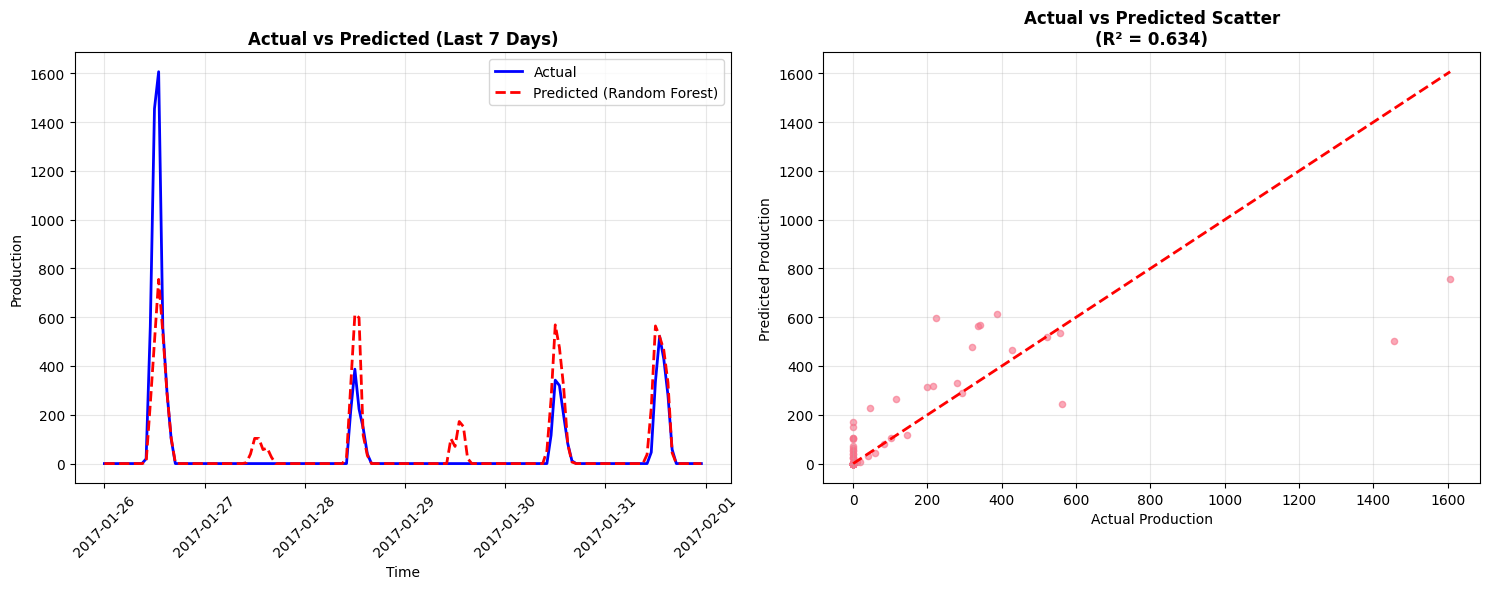

🔍 TOP 10 FEATURE IMPORTANCE (Random Forest):
--------------------------------------------------
radiation           : 0.6548
prod_lag_24         : 0.0926
prod_lag_1          : 0.0552
hour_cos            : 0.0310
air_temperature     : 0.0293
rad_lag_2           : 0.0267
sunshine            : 0.0257
wind_speed          : 0.0244
rad_lag_3           : 0.0231
prod_lag_2          : 0.0163

🔮 SIMPLE FUTURE FORECAST (Next 24 Hours):
----------------------------------------
             timestamp  hour  predicted_production
0  2017-02-01 00:00:00     0                  0.00
1  2017-02-01 01:00:00     1                  0.00
2  2017-02-01 02:00:00     2                  0.00
3  2017-02-01 03:00:00     3                  0.00
4  2017-02-01 04:00:00     4                  0.00
5  2017-02-01 05:00:00     5                  0.00
6  2017-02-01 06:00:00     6                  0.00
7  2017-02-01 07:00:00     7                  0.00
8  2017-02-01 08:00:00     8                  0.00
9  2017-02-01 09:00:

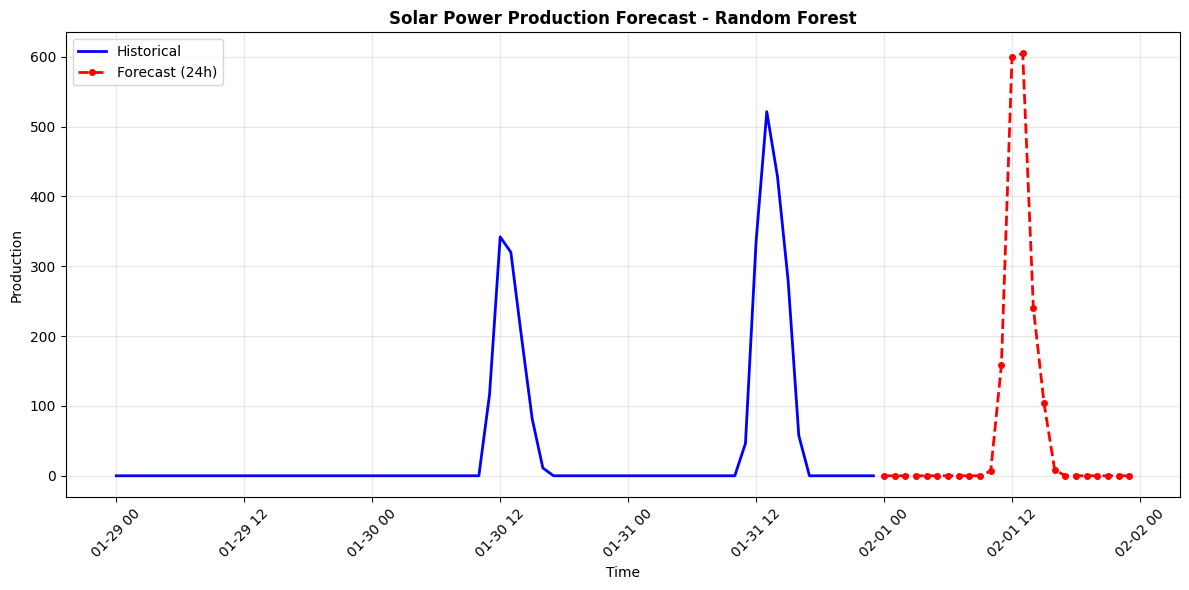


✅ Forecast completed using Random Forest


In [74]:
# Forecasting menggunakan metode sederhana dan machine learning
if 'system_production' in df.columns and SKLEARN_OK:
    
    # Prepare data untuk modeling
    model_df = df.copy()
    
    # Feature engineering - lag features
    for lag in [1, 2, 3, 6, 12, 24]:
        model_df[f'prod_lag_{lag}'] = model_df['system_production'].shift(lag)
    
    # Weather lag features jika tersedia
    if 'radiation' in model_df.columns:
        for lag in [1, 2, 3]:
            model_df[f'rad_lag_{lag}'] = model_df['radiation'].shift(lag)
    
    # Time-based features (circular encoding)
    model_df['hour_sin'] = np.sin(2 * np.pi * model_df['hour'] / 24)
    model_df['hour_cos'] = np.cos(2 * np.pi * model_df['hour'] / 24)
    model_df['month_sin'] = np.sin(2 * np.pi * model_df['month'] / 12)
    model_df['month_cos'] = np.cos(2 * np.pi * model_df['month'] / 12)
    
    # Select features untuk modeling
    feature_cols = [col for col in model_df.columns if 'lag_' in col] + \
                   ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_daytime', 'is_peak_solar']
    
    # Tambahkan weather variables jika ada
    weather_vars = ['radiation', 'air_temperature', 'sunshine', 'wind_speed']
    for var in weather_vars:
        if var in model_df.columns:
            feature_cols.append(var)
    
    # Remove rows dengan missing values
    model_data = model_df.dropna(subset=feature_cols + ['system_production'])
    
    if len(model_data) > 100:  # Minimum data requirement
        print("🤖 FORECASTING MODELS COMPARISON")
        print("="*50)
        print(f"Dataset size: {len(model_data):,} rows")
        print(f"Features used: {len(feature_cols)}")
        print(f"Feature list: {', '.join(feature_cols[:5])}{'...' if len(feature_cols) > 5 else ''}")
        print()
        
        # Train-test split
        train_size = int(len(model_data) * 0.8)
        train_data = model_data.iloc[:train_size]
        test_data = model_data.iloc[train_size:]
        
        X_train = train_data[feature_cols]
        y_train = train_data['system_production']
        X_test = test_data[feature_cols]
        y_test = test_data['system_production']
        
        print(f"Training size: {len(X_train):,}")
        print(f"Testing size: {len(X_test):,}")
        print()
        
        # Model 1: Baseline - Seasonal average
        print("1️⃣ Seasonal Baseline Model")
        hourly_seasonal = train_data.groupby(['hour', 'month'])['system_production'].mean()
        hourly_fallback = train_data.groupby('hour')['system_production'].mean()
        
        def get_seasonal_prediction(hour, month):
            if (hour, month) in hourly_seasonal.index:
                return hourly_seasonal.loc[(hour, month)]
            else:
                return hourly_fallback.loc[hour] if hour in hourly_fallback.index else 0
        
        baseline_pred = [get_seasonal_prediction(row['hour'], row['month']) 
                        for _, row in test_data.iterrows()]
        baseline_mae = mean_absolute_error(y_test, baseline_pred)
        baseline_r2 = r2_score(y_test, baseline_pred)
        
        print(f"   MAE: {baseline_mae:.3f}")
        print(f"   R²:  {baseline_r2:.3f}")
        print()
        
        # Model 2: Linear Regression
        print("2️⃣ Linear Regression")
        lr_model = LinearRegression()
        lr_model.fit(X_train, y_train)
        lr_pred = lr_model.predict(X_test)
        lr_pred = np.maximum(lr_pred, 0)  # Ensure non-negative predictions
        lr_mae = mean_absolute_error(y_test, lr_pred)
        lr_r2 = r2_score(y_test, lr_pred)
        
        print(f"   MAE: {lr_mae:.3f}")
        print(f"   R²:  {lr_r2:.3f}")
        print()
        
        # Model 3: Random Forest
        print("3️⃣ Random Forest")
        rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        rf_model.fit(X_train, y_train)
        rf_pred = rf_model.predict(X_test)
        rf_pred = np.maximum(rf_pred, 0)  # Ensure non-negative predictions
        rf_mae = mean_absolute_error(y_test, rf_pred)
        rf_r2 = r2_score(y_test, rf_pred)
        
        print(f"   MAE: {rf_mae:.3f}")
        print(f"   R²:  {rf_r2:.3f}")
        print()
        
        # Best model selection
        models_performance = {
            'Seasonal Baseline': {'mae': baseline_mae, 'r2': baseline_r2, 'pred': baseline_pred},
            'Linear Regression': {'mae': lr_mae, 'r2': lr_r2, 'pred': lr_pred},
            'Random Forest': {'mae': rf_mae, 'r2': rf_r2, 'pred': rf_pred}
        }
        
        best_model_name = min(models_performance.keys(), key=lambda x: models_performance[x]['mae'])
        best_pred = models_performance[best_model_name]['pred']
        
        print(f"🏆 Best Model: {best_model_name}")
        print(f"   MAE: {models_performance[best_model_name]['mae']:.3f}")
        print(f"   R²:  {models_performance[best_model_name]['r2']:.3f}")
        print()
        
        # Visualisasi prediksi vs aktual
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot 1: Time series comparison (last 7 days)
        last_week = test_data.tail(24*7)  # 7 days
        timestamps = last_week['timestamp']
        actual_values = last_week['system_production']
        predicted_values = best_pred[-len(last_week):] if len(best_pred) >= len(last_week) else best_pred
        
        axes[0].plot(timestamps, actual_values, 'b-', label='Actual', linewidth=2)
        axes[0].plot(timestamps, predicted_values, 'r--', label=f'Predicted ({best_model_name})', linewidth=2)
        axes[0].set_title('Actual vs Predicted (Last 7 Days)', fontweight='bold')
        axes[0].set_xlabel('Time')
        axes[0].set_ylabel('Production')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].tick_params(axis='x', rotation=45)
        
        # Plot 2: Scatter plot actual vs predicted
        axes[1].scatter(y_test, best_pred, alpha=0.6, s=20)
        min_val = min(y_test.min(), min(best_pred))
        max_val = max(y_test.max(), max(best_pred))
        axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
        axes[1].set_xlabel('Actual Production')
        axes[1].set_ylabel('Predicted Production')
        axes[1].set_title(f'Actual vs Predicted Scatter\n(R² = {models_performance[best_model_name]["r2"]:.3f})', 
                         fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Feature importance untuk Random Forest
        if best_model_name == 'Random Forest':
            importance_df = pd.DataFrame({
                'Feature': feature_cols,
                'Importance': rf_model.feature_importances_
            }).sort_values('Importance', ascending=False)
            
            print("🔍 TOP 10 FEATURE IMPORTANCE (Random Forest):")
            print("-" * 50)
            for _, row in importance_df.head(10).iterrows():
                print(f"{row['Feature']:20s}: {row['Importance']:.4f}")
            print()
        
        # Simple future forecast (next 24 hours)
        print("🔮 SIMPLE FUTURE FORECAST (Next 24 Hours):")
        print("-" * 40)
        
        last_timestamp = model_data['timestamp'].max()
        next_24h = pd.date_range(last_timestamp + pd.Timedelta(hours=1), periods=24, freq='H')
        
        forecast_results = []
        for future_time in next_24h:
            hour = future_time.hour
            month = future_time.month
            pred = get_seasonal_prediction(hour, month)
            
            forecast_results.append({
                'timestamp': future_time,
                'hour': hour,
                'predicted_production': pred
            })
        
        forecast_df = pd.DataFrame(forecast_results)
        print(forecast_df[['timestamp', 'hour', 'predicted_production']].round(2))
        
        # Plot simple forecast
        plt.figure(figsize=(12, 6))
        
        # Historical data (last 3 days)
        hist_data = model_data.tail(72)
        plt.plot(hist_data['timestamp'], hist_data['system_production'], 
                'b-', label='Historical', linewidth=2)
        
        # Forecast
        plt.plot(forecast_df['timestamp'], forecast_df['predicted_production'], 
                'r--', label='Forecast (24h)', linewidth=2, marker='o', markersize=4)
        
        plt.title(f'Solar Power Production Forecast - {best_model_name}', fontweight='bold')
        plt.xlabel('Time')
        plt.ylabel('Production')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        print(f"\n✅ Forecast completed using {best_model_name}")
        
    else:
        print("❌ Insufficient data for modeling (need at least 100 rows)")
else:
    if not SKLEARN_OK:
        print("⚠️ Scikit-learn not available - using simple forecasting")
        
        # Simple seasonal forecast
        if 'system_production' in df.columns:
            hourly_avg = df.groupby('hour')['system_production'].mean()
            next_24h = pd.date_range(df['timestamp'].max() + pd.Timedelta(hours=1), periods=24, freq='H')
            
            simple_forecast = []
            for ts in next_24h:
                pred = hourly_avg.get(ts.hour, 0)
                simple_forecast.append({'timestamp': ts, 'predicted': pred})
            
            simple_df = pd.DataFrame(simple_forecast)
            print("📊 SIMPLE HOURLY AVERAGE FORECAST:")
            print(simple_df.round(2))
    else:
        print("⚠️ system_production column not found")

## 5. Business Insights & Rekomendasi

In [75]:
# Business Insights dan Rekomendasi
print("🏭 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*60)

if 'system_production' in df.columns:
    # Key Performance Indicators
    total_production = df['system_production'].sum()
    avg_daily_production = df.groupby(df['timestamp'].dt.date)['system_production'].sum().mean()
    max_hourly_production = df['system_production'].max()
    
    print("📊 KEY PERFORMANCE INDICATORS:")
    print(f"• Total Production (periode): {total_production:,.2f}")
    print(f"• Average Daily Production: {avg_daily_production:,.2f}")
    print(f"• Peak Hourly Production: {max_hourly_production:,.2f}")
    
    # Production efficiency
    if 'radiation' in df.columns:
        # Solar efficiency analysis
        production_hours = df[df['system_production'] > 0]
        if len(production_hours) > 0:
            avg_efficiency = production_hours['solar_efficiency'].mean() if 'solar_efficiency' in df.columns else 0
            print(f"• Average Solar Efficiency: {avg_efficiency:.4f}")
    
    # Capacity factor (assume peak capacity = max production)
    capacity_factor = (total_production / (max_hourly_production * len(df))) * 100 if max_hourly_production > 0 else 0
    print(f"• Capacity Factor: {capacity_factor:.2f}%")
    print()
    
    # Operational insights
    print("⚡ OPERATIONAL INSIGHTS:")
    
    # Peak performance hours
    hourly_avg = df.groupby('hour')['system_production'].mean()
    peak_hours = hourly_avg.nlargest(3)
    print("• Top 3 Peak Performance Hours:")
    for hour, prod in peak_hours.items():
        print(f"  - {hour:02d}:00 → {prod:.2f} average production")
    
    # Low performance identification
    production_data = df[df['system_production'] > 0]
    if len(production_data) > 0:
        low_threshold = production_data['system_production'].quantile(0.1)
        low_perf_hours = production_data[production_data['system_production'] < low_threshold]
        
        if len(low_perf_hours) > 0:
            print(f"• Low Performance Alert: {len(low_perf_hours)} hours with production < {low_threshold:.2f}")
            common_low_hours = low_perf_hours['hour'].value_counts().head(3)
            print("  Most common low-performance hours:")
            for hour, count in common_low_hours.items():
                print(f"    - {hour:02d}:00 ({count} occurrences)")
    
    # Weather correlation insights
    if 'radiation' in df.columns:
        radiation_corr = df['radiation'].corr(df['system_production'])
        print(f"• Radiation-Production Correlation: {radiation_corr:.3f}")
        if radiation_corr < 0.7:
            print("  ⚠️ Warning: Lower than expected correlation with radiation")
            print("    → Check for panel degradation, soiling, or shading issues")
    
    if 'air_temperature' in df.columns:
        temp_corr = df['air_temperature'].corr(df['system_production'])
        print(f"• Temperature-Production Correlation: {temp_corr:.3f}")
        if temp_corr < 0:
            print("  ℹ️ Negative correlation indicates temperature-related efficiency loss")
    
    print()
    
    # Maintenance recommendations
    print("🔧 MAINTENANCE RECOMMENDATIONS:")
    
    # Seasonality check
    if len(df['month'].unique()) > 1:
        monthly_avg = df.groupby('month')['system_production'].mean()
        worst_month = monthly_avg.idxmin()
        best_month = monthly_avg.idxmax()
        month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        
        print(f"• Peak Season: {month_names[best_month]} (avg: {monthly_avg[best_month]:.2f})")
        print(f"• Low Season: {month_names[worst_month]} (avg: {monthly_avg[worst_month]:.2f})")
        print("  → Schedule major maintenance during low season")
    
    # Performance consistency
    daily_production = df.groupby(df['timestamp'].dt.date)['system_production'].sum()
    cv = daily_production.std() / daily_production.mean() if daily_production.mean() > 0 else 0
    print(f"• Daily Production Variability (CV): {cv:.3f}")
    if cv > 0.5:
        print("  ⚠️ High variability detected - investigate weather dependencies")
    
    print("• Regular cleaning schedule recommended")
    print("• Monitor inverter performance during peak hours")
    print("• Check panel alignment and shading quarterly")
    print()
    
    # Financial insights
    print("💰 BUSINESS VALUE:")
    print("• Use forecasting models for:")
    print("  - Energy trading and grid scheduling")
    print("  - Maintenance planning optimization") 
    print("  - Performance benchmarking")
    print("  - Revenue forecasting")
    print()
    
    # Data quality assessment
    print("📋 DATA QUALITY ASSESSMENT:")
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    critical_missing = missing_pct[missing_pct > 10]
    
    if len(critical_missing) > 0:
        print("⚠️ Critical Missing Data (>10%):")
        for col, pct in critical_missing.items():
            print(f"  - {col}: {pct}%")
        print("  → Improve data collection systems")
    else:
        print("✅ Data quality is acceptable (< 10% missing for all variables)")
    
    zero_production_pct = (df['system_production'] == 0).sum() / len(df) * 100
    print(f"• Zero production periods: {zero_production_pct:.1f}% of total time")
    if zero_production_pct > 60:  # Expect ~50% for nighttime
        print("  ✅ Normal (includes nighttime)")
    else:
        print("  ⚠️ Check for equipment issues")
    
else:
    print("⚠️ system_production column not available for business analysis")

print("\\n" + "="*60)
print("📈 DASHBOARD SUMMARY COMPLETE")
print("This analysis provides:")
print("✓ Temporal patterns and seasonality insights")
print("✓ Weather correlation analysis") 
print("✓ Performance forecasting capabilities")
print("✓ Operational recommendations")
print("✓ Data quality assessment")
print("="*60)

🏭 BUSINESS INSIGHTS & RECOMMENDATIONS
📊 KEY PERFORMANCE INDICATORS:
• Total Production (periode): 51,459.62
• Average Daily Production: 1,659.99
• Peak Hourly Production: 1,606.33
• Average Solar Efficiency: 7.5035
• Capacity Factor: 4.31%

⚡ OPERATIONAL INSIGHTS:
• Top 3 Peak Performance Hours:
  - 12:00 → 572.30 average production
  - 13:00 → 565.56 average production
  - 14:00 → 237.61 average production
• Low Performance Alert: 14 hours with production < 33.13
  Most common low-performance hours:
    - 16:00 (8 occurrences)
    - 15:00 (3 occurrences)
    - 14:00 (1 occurrences)
• Radiation-Production Correlation: 0.777
• Temperature-Production Correlation: 0.119

🔧 MAINTENANCE RECOMMENDATIONS:
• Daily Production Variability (CV): 0.716
  ⚠️ High variability detected - investigate weather dependencies
• Regular cleaning schedule recommended
• Monitor inverter performance during peak hours
• Check panel alignment and shading quarterly

💰 BUSINESS VALUE:
• Use forecasting models for: